In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(
    r"C:\Users\Dell\Downloads\Retail_Sales_EDA_Dataset_UTF8.csv",
    encoding="utf-8"
)

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,INV10001,10011,LED Bulb,2,2025-01-14 19:17:00,7.50,10032,France
1,INV10002,10003,Desk Lamp,2,2025-12-14 19:57:00,18.00,10070,United Kingdom
2,INV10003,10010,Phone Stand,7,2025-01-18 08:05:00,9.99,10028,France
3,INV10004,10009,Keyboard,1,2025-10-16 11:45:00,39.99,10084,Belgium
4,INV10005,10009,Keyboard,7,2025-04-24 15:37:00,39.99,10036,India


In [4]:
df.shape

(250, 8)

In [5]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    250 non-null    str    
 1   StockCode    250 non-null    int64  
 2   Description  250 non-null    str    
 3   Quantity     250 non-null    int64  
 4   InvoiceDate  250 non-null    str    
 5   UnitPrice    250 non-null    float64
 6   CustomerID   250 non-null    int64  
 7   Country      250 non-null    str    
dtypes: float64(1), int64(3), str(4)
memory usage: 15.8 KB


In [7]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,StockCode,Quantity,UnitPrice,CustomerID
count,250.000000,250.000000,250.000000,250.000000
mean,10007.984000,4.504000,18.862760,10056.580000
std,4.361172,2.224811,14.697217,34.191223
min,10001.000000,1.000000,3.250000,10001.000000
25%,10004.000000,3.000000,7.500000,10030.250000
50%,10008.000000,5.000000,14.000000,10051.000000
75%,10012.000000,6.000000,24.990000,10086.000000
max,10015.000000,8.000000,55.000000,10120.000000


In [12]:
df.dtypes

InvoiceNo          str
StockCode        int64
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID       int64
Country            str
dtype: object

In [13]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [14]:
df.dtypes

InvoiceNo                 str
StockCode               int64
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID              int64
Country                   str
dtype: object

In [15]:
df['Sales']=df['Quantity']*df['UnitPrice']

In [16]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,INV10001,10011,LED Bulb,2,2025-01-14 19:17:00,7.50,10032,France,15.00
1,INV10002,10003,Desk Lamp,2,2025-12-14 19:57:00,18.00,10070,United Kingdom,36.00
2,INV10003,10010,Phone Stand,7,2025-01-18 08:05:00,9.99,10028,France,69.93
3,INV10004,10009,Keyboard,1,2025-10-16 11:45:00,39.99,10084,Belgium,39.99
4,INV10005,10009,Keyboard,7,2025-04-24 15:37:00,39.99,10036,India,279.93


In [17]:
df['Sales'].sum()

np.float64(22297.7)

In [18]:
df['Sales'].mean()

np.float64(89.1908)

In [19]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['MonthName'] = df['InvoiceDate'].dt.month_name()

In [20]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales,Year,Month,MonthName
0,INV10001,10011,LED Bulb,2,2025-01-14 19:17:00,7.50,10032,France,15.00,2025,1,January
1,INV10002,10003,Desk Lamp,2,2025-12-14 19:57:00,18.00,10070,United Kingdom,36.00,2025,12,December
2,INV10003,10010,Phone Stand,7,2025-01-18 08:05:00,9.99,10028,France,69.93,2025,1,January
3,INV10004,10009,Keyboard,1,2025-10-16 11:45:00,39.99,10084,Belgium,39.99,2025,10,October
4,INV10005,10009,Keyboard,7,2025-04-24 15:37:00,39.99,10036,India,279.93,2025,4,April


In [21]:
df.to_csv(
    "Retail_Sales_EDA_Cleaned.csv",
    index=False,
    encoding="utf-8"
)

In [22]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False)

top_products.head(10)

Description
Desk Lamp         98
Wireless Mouse    96
T-Shirt           94
Water Bottle      86
Keyboard          84
Headphones        81
LED Bulb          79
Phone Stand       75
Lunch Box         74
Ceramic Mug       74
Name: Quantity, dtype: int64

In [23]:
top_sales_products = df.groupby('Description')['Sales'].sum().sort_values(ascending=False)

top_sales_products.head(10)

Description
Headphones        3645.00
Keyboard          3359.16
Sneakers          3355.00
Wireless Mouse    2399.04
Desk Lamp         1764.00
T-Shirt           1504.00
Backpack          1248.00
Water Bottle      1075.00
Coffee Beans       896.00
Lunch Box          832.50
Name: Sales, dtype: float64

In [24]:
country_sales = df.groupby('Country')['Sales'].sum().sort_values(ascending=False)

country_sales

Country
Belgium           4465.12
Spain             4115.04
United Kingdom    3323.66
Germany           3060.69
Netherlands       2523.08
India             2483.64
France            2326.47
Name: Sales, dtype: float64

In [25]:
monthly_sales = df.groupby('MonthName')['Sales'].sum()

monthly_sales

MonthName
April        1898.54
August       2661.39
December     1635.20
February     2046.30
January      1258.82
July         1311.47
June         1606.09
March        2151.17
May          2030.18
November     2548.85
October      2113.85
September    1035.84
Name: Sales, dtype: float64

In [26]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_sales = df.groupby('MonthName')['Sales'].sum().reindex(month_order)

monthly_sales

MonthName
January      1258.82
February     2046.30
March        2151.17
April        1898.54
May          2030.18
June         1606.09
July         1311.47
August       2661.39
September    1035.84
October      2113.85
November     2548.85
December     1635.20
Name: Sales, dtype: float64

In [27]:
yearly_sales = df.groupby('Year')['Sales'].sum()

yearly_sales

Year
2025    22297.7
Name: Sales, dtype: float64

In [28]:
import matplotlib.pyplot as plt

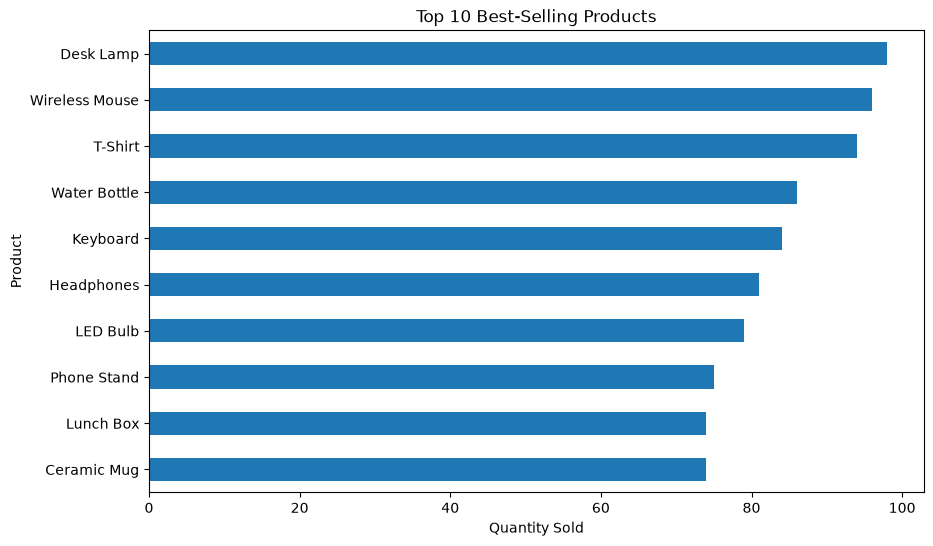

In [29]:
top_products.head(10).sort_values().plot(kind='barh', figsize=(10,6))

plt.title('Top 10 Best-Selling Products')
plt.xlabel('Quantity Sold')
plt.ylabel('Product')
plt.show()

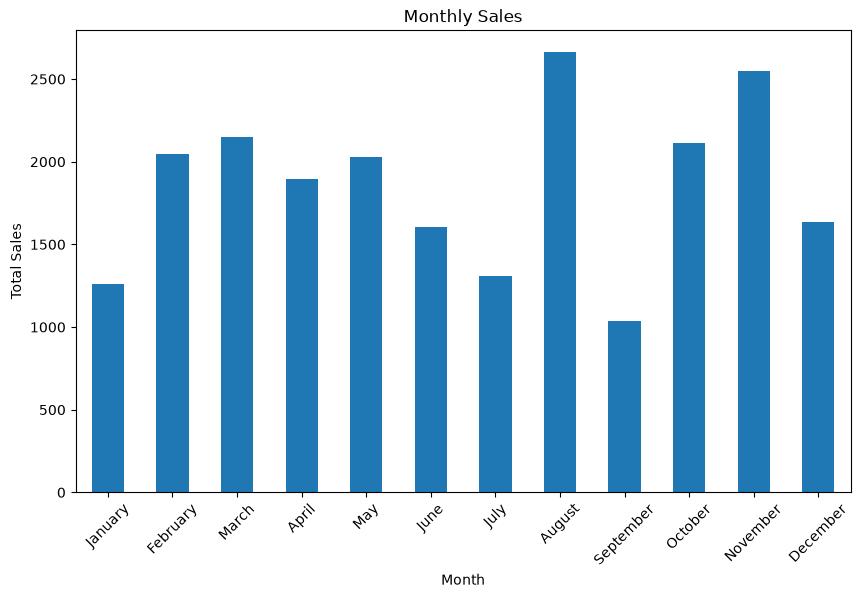

In [30]:
monthly_sales.plot(kind='bar', figsize=(10,6))

plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

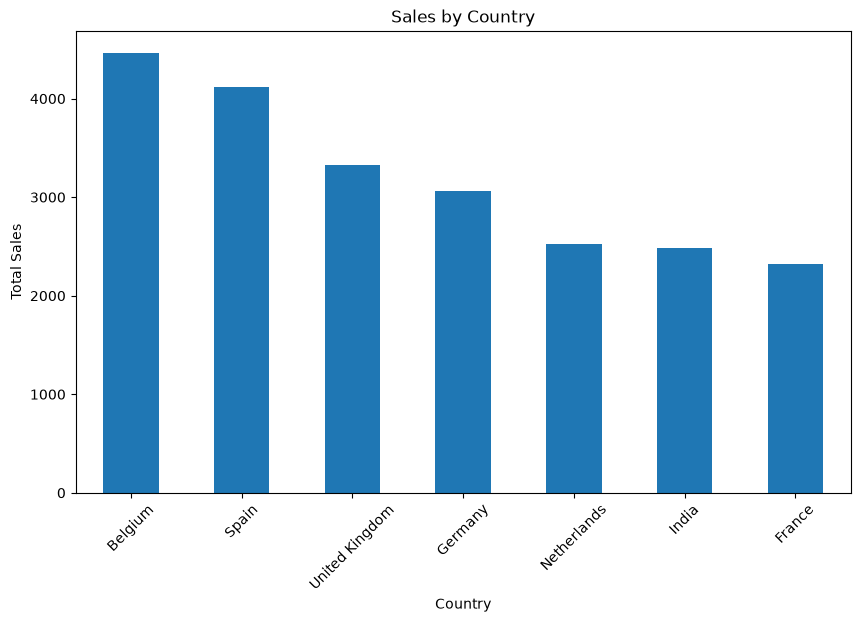

In [31]:
country_sales.plot(kind='bar', figsize=(10,6))

plt.title('Sales by Country')
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

In [32]:
total_revenue = df['Sales'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 22297.7


In [33]:
total_quantity = df['Quantity'].sum()
print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 1126


In [34]:
total_orders = df['InvoiceNo'].nunique()
print("Total Orders:", total_orders)

Total Orders: 250


In [35]:
total_customers = df['CustomerID'].nunique()
print("Total Customers:", total_customers)

Total Customers: 102


In [36]:
average_order_value = total_revenue / total_orders

print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 89.19


In [37]:
highest_transaction = df.loc[df['Sales'].idxmax()]

highest_transaction

InvoiceNo                 INV10049
StockCode                    10013
Description               Sneakers
Quantity                         8
InvoiceDate    2025-03-22 11:18:00
UnitPrice                     55.0
CustomerID                   10028
Country             United Kingdom
Sales                        440.0
Year                          2025
Month                            3
MonthName                    March
Name: 48, dtype: object

In [38]:
most_expensive = df.loc[df['UnitPrice'].idxmax()]

most_expensive

InvoiceNo                 INV10025
StockCode                    10013
Description               Sneakers
Quantity                         5
InvoiceDate    2025-11-26 13:07:00
UnitPrice                     55.0
CustomerID                   10038
Country                      Spain
Sales                        275.0
Year                          2025
Month                           11
MonthName                 November
Name: 24, dtype: object

In [39]:
most_purchased_product = df.groupby('Description')['Quantity'].sum().idxmax()

print("Most Purchased Product:", most_purchased_product)

Most Purchased Product: Desk Lamp


In [40]:
customer_sales = (
    df.groupby('CustomerID')['Sales']
      .sum()
      .sort_values(ascending=False)
)

customer_sales.head(10)

CustomerID
10038    742.15
10037    686.42
10082    619.92
10023    596.00
10007    582.50
10049    555.46
10009    533.00
10028    509.93
10031    484.25
10036    478.89
Name: Sales, dtype: float64

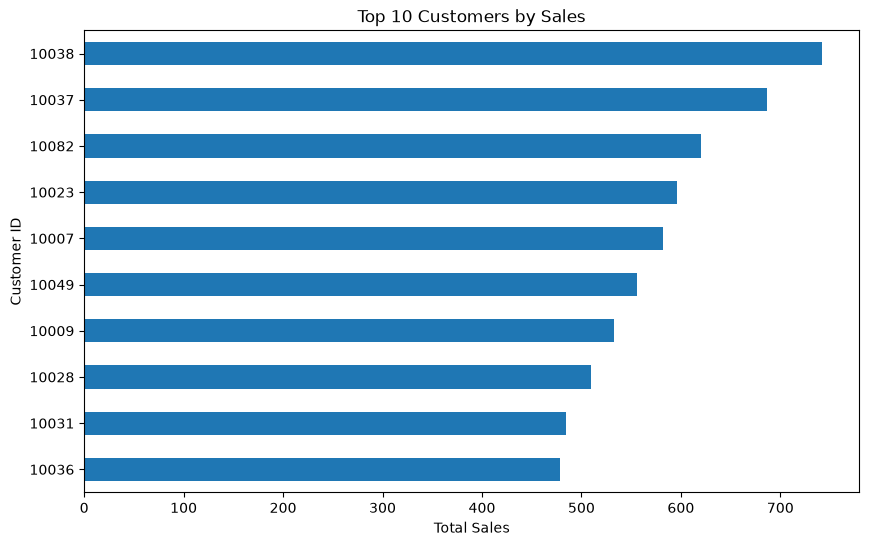

In [41]:
customer_sales.head(10).sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Top 10 Customers by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Customer ID')
plt.show()

In [42]:
daily_sales = df.groupby('InvoiceDate')['Sales'].sum()

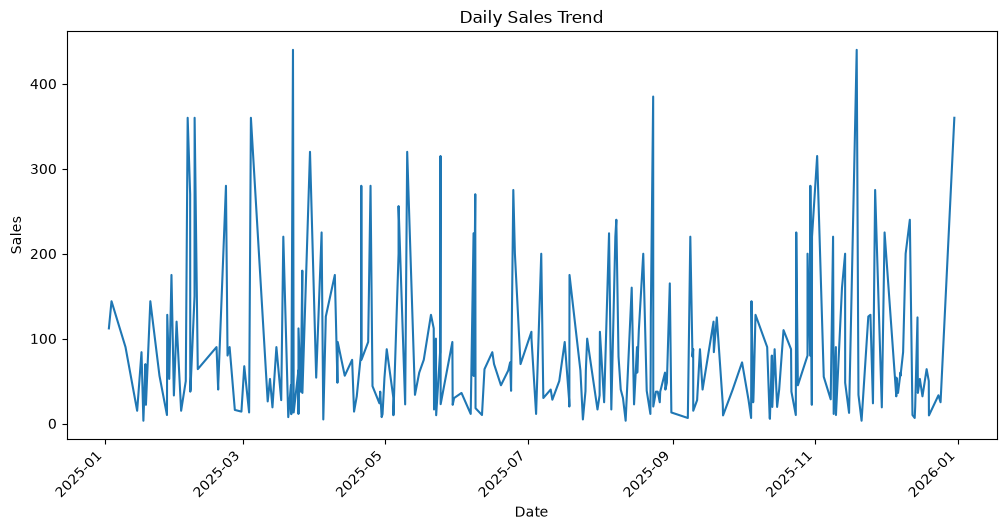

In [43]:
daily_sales.plot(figsize=(12,6))

plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

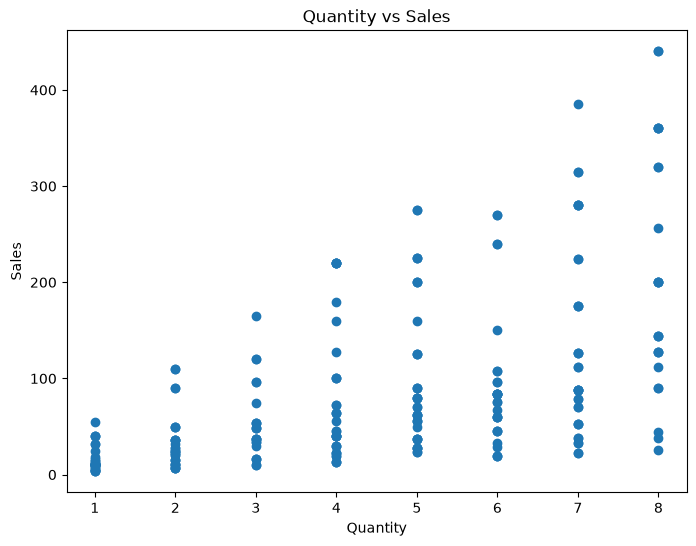

In [44]:
plt.figure(figsize=(8,6))

plt.scatter(df['Quantity'], df['Sales'])

plt.title('Quantity vs Sales')
plt.xlabel('Quantity')
plt.ylabel('Sales')

plt.show()

In [45]:
df[['Quantity', 'UnitPrice', 'Sales']].corr()

,Quantity,UnitPrice,Sales
Quantity,1.000000,0.129973,0.568892
UnitPrice,0.129973,1.000000,0.809527
Sales,0.568892,0.809527,1.000000


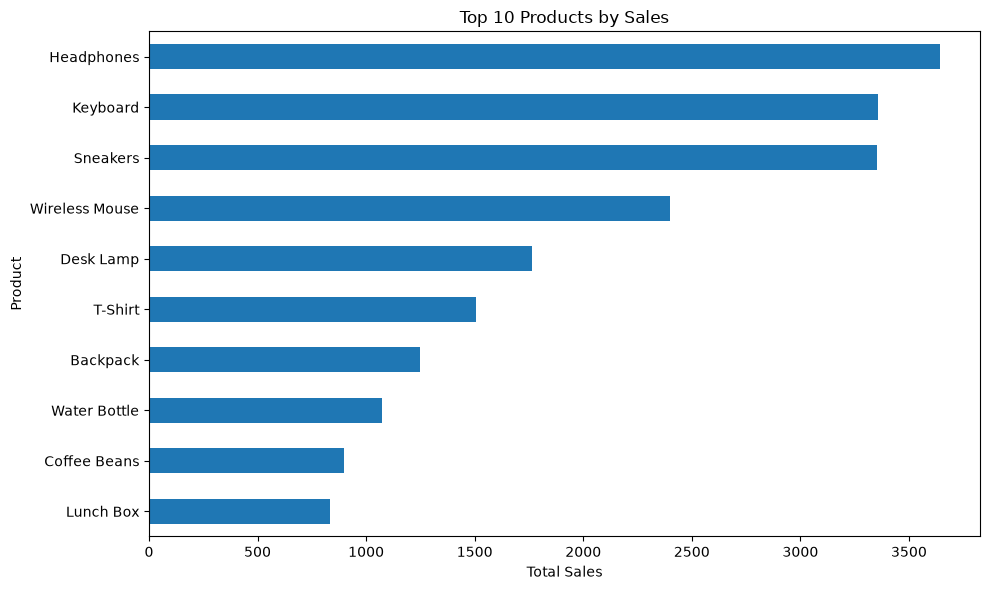

In [46]:
plt.figure(figsize=(10,6))

top_sales_products.head(10).sort_values().plot(kind='barh')

plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

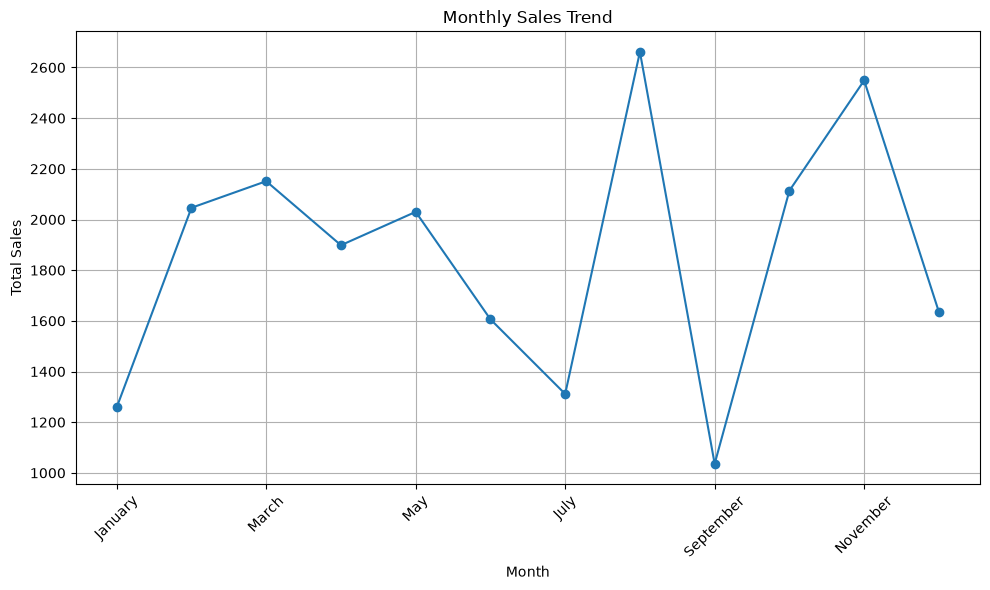

In [47]:
plt.figure(figsize=(10,6))

monthly_sales.plot(marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

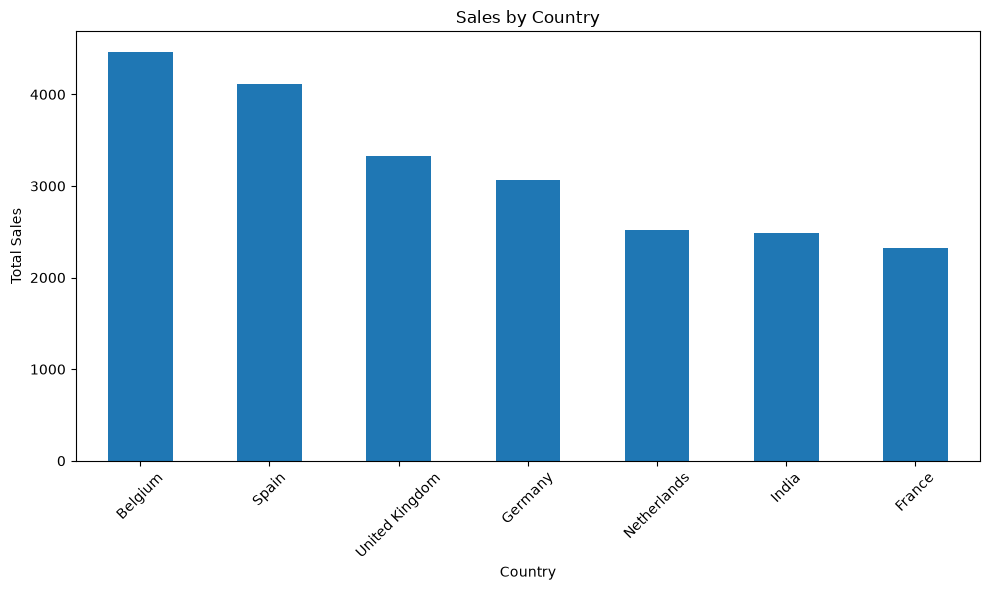

In [48]:
plt.figure(figsize=(10,6))

country_sales.plot(kind='bar')

plt.title('Sales by Country')
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

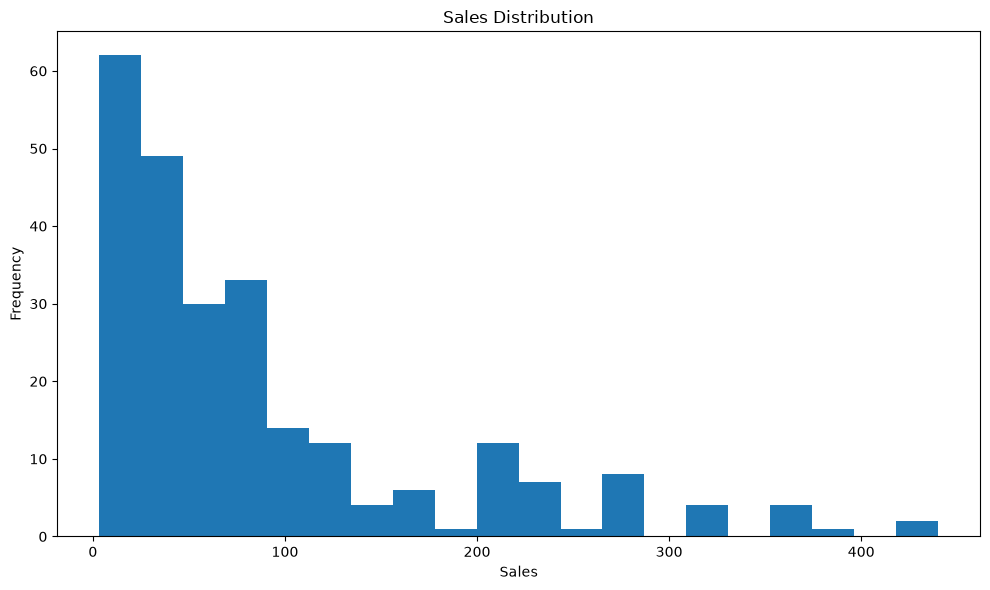

In [49]:
plt.figure(figsize=(10,6))

plt.hist(df['Sales'], bins=20)

plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

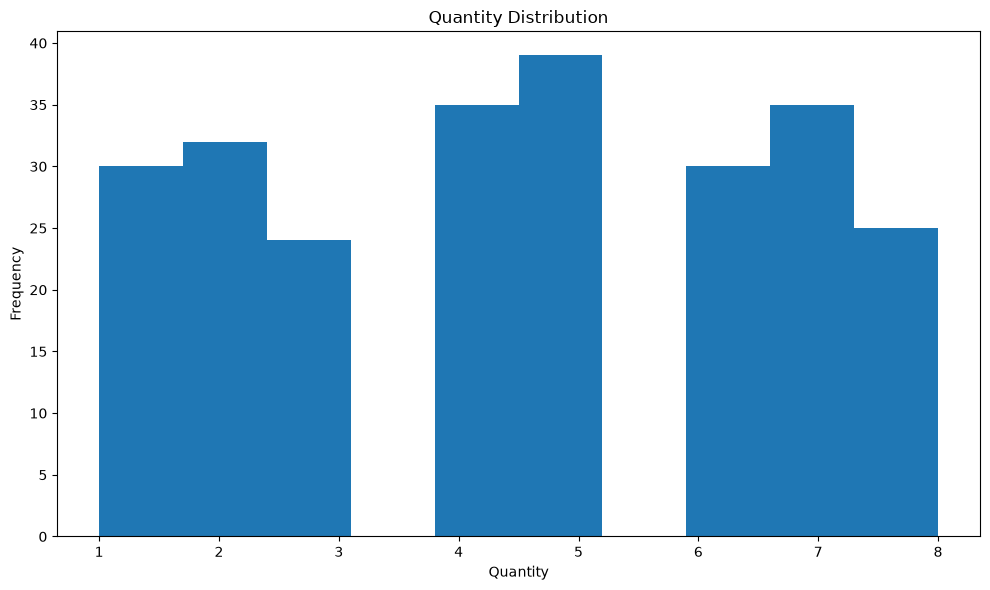

In [50]:
plt.figure(figsize=(10,6))

plt.hist(df['Quantity'], bins=10)

plt.title('Quantity Distribution')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

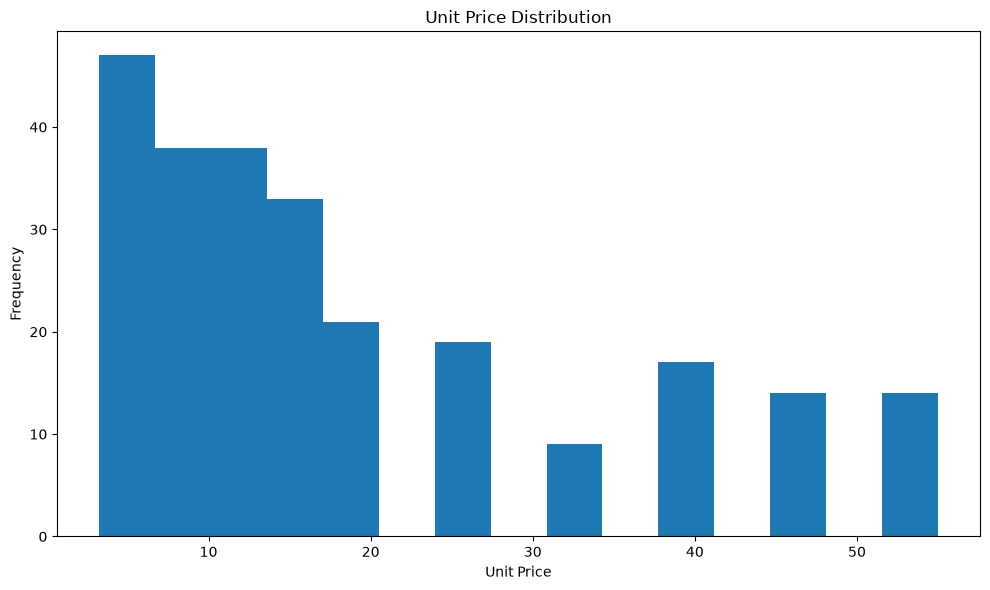

In [51]:
plt.figure(figsize=(10,6))

plt.hist(df['UnitPrice'], bins=15)

plt.title('Unit Price Distribution')
plt.xlabel('Unit Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [52]:
print("========== RETAIL SALES EDA SUMMARY ==========")

print("Total Revenue:", round(df['Sales'].sum(), 2))
print("Total Quantity Sold:", df['Quantity'].sum())
print("Total Orders:", df['InvoiceNo'].nunique())
print("Total Customers:", df['CustomerID'].nunique())

print("\nTop Product by Quantity:")
print(top_products.index[0])

print("\nTop Product by Sales:")
print(top_sales_products.index[0])

print("\nTop Country by Sales:")
print(country_sales.index[0])

print("\nBest Sales Month:")
print(monthly_sales.idxmax())

print("\nHighest Sales Month Value:")
print(round(monthly_sales.max(), 2))

========== RETAIL SALES EDA SUMMARY ==========
Total Revenue: 22297.7
Total Quantity Sold: 1126
Total Orders: 250
Total Customers: 102

Top Product by Quantity:
Desk Lamp

Top Product by Sales:
Headphones

Top Country by Sales:
Belgium

Best Sales Month:
August

Highest Sales Month Value:
2661.39


In [53]:
df.to_csv(
    "Retail_Sales_EDA_Final.csv",
    index=False,
    encoding="utf-8"
)

In [54]:
insights = {
    "Metric": [
        "Total Revenue",
        "Total Quantity Sold",
        "Total Orders",
        "Total Customers",
        "Average Order Value",
        "Top Product by Quantity",
        "Top Product by Sales",
        "Top Country by Sales",
        "Best Sales Month"
    ],
    "Value": [
        round(df['Sales'].sum(), 2),
        df['Quantity'].sum(),
        df['InvoiceNo'].nunique(),
        df['CustomerID'].nunique(),
        round(df['Sales'].sum() / df['InvoiceNo'].nunique(), 2),
        top_products.index[0],
        top_sales_products.index[0],
        country_sales.index[0],
        monthly_sales.idxmax()
    ]
}

insights_df = pd.DataFrame(insights)

insights_df

,Metric,Value
0,Total Revenue,22297.7
1,Total Quantity Sold,1126
2,Total Orders,250
3,Total Customers,102
4,Average Order Value,89.19
5,Top Product by Quantity,Desk Lamp
6,Top Product by Sales,Headphones
7,Top Country by Sales,Belgium
8,Best Sales Month,August


In [55]:
import seaborn as sns

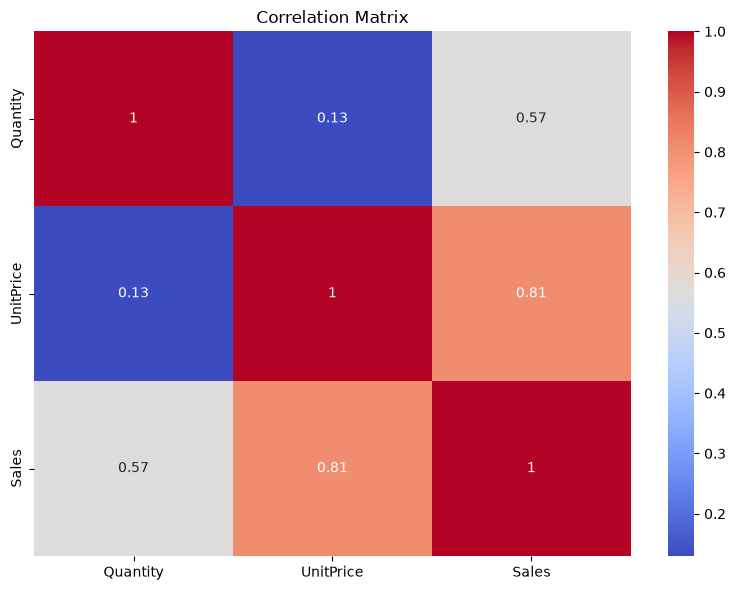

In [56]:
plt.figure(figsize=(8,6))

correlation = df[['Quantity', 'UnitPrice', 'Sales']].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [57]:
product_summary = (
    df.groupby('Description')
      .agg(
          Total_Quantity=('Quantity', 'sum'),
          Total_Sales=('Sales', 'sum'),
          Average_Price=('UnitPrice', 'mean')
      )
      .sort_values('Total_Sales', ascending=False)
)

product_summary.head(10)

,Total_Quantity,Total_Sales,Average_Price
Description,,,
Headphones,81,3645.00,45.00
Keyboard,84,3359.16,39.99
Sneakers,61,3355.00,55.00
Wireless Mouse,96,2399.04,24.99
Desk Lamp,98,1764.00,18.00
T-Shirt,94,1504.00,16.00
Backpack,39,1248.00,32.00
Water Bottle,86,1075.00,12.50
Coffee Beans,64,896.00,14.00


In [58]:
product_summary.to_csv(
    "Product_Sales_Analysis.csv",
    encoding="utf-8"
)

In [59]:
#BUSINESS RECOMMENDATIONS

1.**Focus on high-performing products:**
   Products generating the highest sales should receive greater attention in inventory planning and marketing.

2.**Monitor monthly sales trends:**
   Sales patterns across months can help businesses plan promotions and inventory according to demand.

3.**Identify valuable customers:**
   Customer-level sales analysis can help identify customers contributing significantly to revenue.

4.**Optimize inventory:**
   Products with high quantities sold should be monitored carefully to reduce the risk of stockouts.

5.**Analyze country-wise performance:**
   Countries generating higher sales can be targeted for stronger marketing and distribution strategies.

SyntaxError: invalid syntax (739019097.py, line 3)

In [ ]:
#CONCLUSION

The Retail Sales Exploratory Data Analysis project provides an overview of sales performance, customer activity, product demand, and geographical sales distribution.

Using Python, Pandas, Matplotlib, and data visualization techniques, the dataset was cleaned, transformed, analyzed, and visualized.

The analysis identifies important patterns in product sales, monthly performance, customer contribution, and country-wise revenue. These insights can support better inventory planning, customer targeting, and sales strategy.

Overall, the project demonstrates the practical use of Python-based data analysis for extracting meaningful business insights from retail data.